# **Project Title: Automated Customer Reviews Analysis using NLP**

#  Import Libraries


In [147]:
!pip install transformers datasets

In [214]:
# General Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and Transformers
import re
import nltk
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix ,accuracy_score, precision_recall_fscore_support
from sklearn.utils import resample
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# HuggingFace Dataset
from datasets import Dataset, DatasetDict

# Clustering & Embedding
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Visualization
from wordcloud import WordCloud

# Optional: Warnings
import warnings
warnings.filterwarnings("ignore")



# 2. Load and Preprocess Data


In [215]:
df = pd.read_csv(
    "/content/Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv",
    usecols=["name", "categories", "reviews.rating", "reviews.text", "reviews.title","reviews.doRecommend"]
)


In [216]:
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = re.sub(r'<.*?>', ' ', text)  # Remove HTML tags
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # Remove emojis and non-ASCII characters
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\@\w+|\#', ' ', text)  # Remove mentions and hashtags
    text = re.sub(r"[^a-zA-Z']", ' ', text)  # Remove numbers and special characters
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Columns to clean
text_columns = ["name", "reviews.text", "reviews.title", "categories", "reviews.doRecommend"]

# Apply the clean_text function safely
for col in text_columns:
    df[col] = df[col].apply(lambda x: clean_text(str(x)) if not pd.isnull(x) else "")

# Optional: Check result
print("✅ Data after cleaning:")
print(df.head())

✅ Data after cleaning:
                                                name  \
0  amazonbasics aaa performance alkaline batterie...   
1  amazonbasics aaa performance alkaline batterie...   
2  amazonbasics aaa performance alkaline batterie...   
3  amazonbasics aaa performance alkaline batterie...   
4  amazonbasics aaa performance alkaline batterie...   

                                          categories reviews.doRecommend  \
0  aa aaa health electronics health household cam...                       
1  aa aaa health electronics health household cam...                       
2  aa aaa health electronics health household cam...                       
3  aa aaa health electronics health household cam...                       
4  aa aaa health electronics health household cam...                       

   reviews.rating                                       reviews.text  \
0               3  i order of them and one of the item is bad qua...   
1               4  bulk is always the l

##Exploratory Data Analysis (EDA)

In [217]:
# Show the first 5 rows of the dataset
print("="*30)
print("📌 First 5 rows:")
print(df.head())

# Show the last 5 rows of the dataset
print("="*30)
print("📌 Last 5 rows:")
print(df.tail())

# General info about the dataset (columns, non-null values, data types)
print("="*30)
print("📌 Dataset info:")
df.info()

# Show data types of each column
print("="*30)
print("📌 Data types of each column:")
print(df.dtypes)

# Show the shape of the dataset (rows, columns)
print("="*30)
print("📌 Dataset shape (rows, columns):")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Create a copy of the dataset as a backup
data = df.copy()

# Check for missing values in each column
print("="*30)
print("📌 Missing values per column:")
print(df.isnull().sum())

# Drop columns that contain any missing values
df.dropna(inplace=True)

# Show remaining columns after dropping those with NaNs
print("="*30)
print("📌 Remaining columns after removing those with missing values:")
print(df.columns.tolist())



📌 First 5 rows:
                                                name  \
0  amazonbasics aaa performance alkaline batterie...   
1  amazonbasics aaa performance alkaline batterie...   
2  amazonbasics aaa performance alkaline batterie...   
3  amazonbasics aaa performance alkaline batterie...   
4  amazonbasics aaa performance alkaline batterie...   

                                          categories reviews.doRecommend  \
0  aa aaa health electronics health household cam...                       
1  aa aaa health electronics health household cam...                       
2  aa aaa health electronics health household cam...                       
3  aa aaa health electronics health household cam...                       
4  aa aaa health electronics health household cam...                       

   reviews.rating                                       reviews.text  \
0               3  i order of them and one of the item is bad qua...   
1               4  bulk is always the less exp

# Sentiment Classification

In [223]:
# Map star ratings to sentiment classes
def map_rating_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

# Apply the mapping function to the dataset
df["sentiment"] = df["reviews.rating"].apply(map_rating_to_sentiment)

# Show the distribution of sentiment classes
# Show the distribution of sentiment classes
print("="*30)
print("📌 Sentiment distribution:")
print(df["sentiment"].value_counts())

# Convert sentiment labels to numeric labels (0, 1, 2)
label_mapping = {"Negative": 0, "Neutral": 1, "Positive": 2}
df["label"] = df["sentiment"].map(label_mapping)

📌 Sentiment distribution:
sentiment
Positive    25545
Negative     1581
Neutral      1206
Name: count, dtype: int64


Train-Test Split


In [225]:
# Split the data into training and test sets
train_texts, test_texts, train_labels, test_labels = train_test_split(df["reviews.text"], df["label"], test_size=0.2, random_state=42)

# Convert train_texts and test_texts to DataFrame for further processing
train_df = pd.DataFrame({'text': train_texts, 'labels': train_labels})
test_df = pd.DataFrame({'text': test_texts, 'labels': test_labels})


In [227]:
# Separate classes in training data
df_train_positive = train_df[train_df['labels'] == 2]
df_train_negative = train_df[train_df['labels'] == 0]
df_train_neutral = train_df[train_df['labels'] == 1]

# Oversample Negative and Neutral to 5,000 samples each
df_train_negative_upsampled = resample(df_train_negative,
                                       replace=True,     # sample with replacement
                                       n_samples=5000,   # target number
                                       random_state=42)  # for reproducibility

df_train_neutral_upsampled = resample(df_train_neutral,
                                      replace=True,
                                      n_samples=5000,
                                      random_state=42)

# Downsample Positive to 5,000 samples
df_train_positive_downsampled = resample(df_train_positive,
                                         replace=False,   # sample without replacement
                                         n_samples=5000,
                                         random_state=42)

# Combine the balanced dataset
train_df_balanced = pd.concat([df_train_positive_downsampled,
                               df_train_negative_upsampled,
                               df_train_neutral_upsampled])

# Shuffle the data (optional but recommended)
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
# Check class distribution
print("Class Distribution in Training Set (After Oversampling):")
train_balanced_counts = train_df_balanced['labels'].value_counts()
print(train_balanced_counts)


Class Distribution in Training Set (After Oversampling):
labels
1    5000
0    5000
2    5000
Name: count, dtype: int64


* Create HuggingFace Dataset


In [228]:
# Convert to HuggingFace Datasets
train_texts = train_df_balanced['text']
train_labels = train_df_balanced['labels']
test_texts = test_df['text']
test_labels = test_df['labels']

train_dataset = Dataset.from_dict({"text": train_texts.tolist(), "label": train_labels.tolist()})
test_dataset = Dataset.from_dict({"text": test_texts.tolist(), "label": test_labels.tolist()})

dataset = DatasetDict({"train": train_dataset, "test": test_dataset})

# Show the first entry in the train dataset
print(dataset["train"][0])


{'text': 'these have a very short life i do not recommend this brand', 'label': 1}


## Tokenization and Dataset Preparation


In [229]:
# Load tokenizer and model
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Tokenize function
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=512)

# Tokenize dataset
encoded_dataset = dataset.map(tokenize, batched=True)

# Define metrics for evaluation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5667 [00:00<?, ? examples/s]

In [230]:
# Train and evaluate
trainer.train()
trainer.evaluate()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.565400,0.370599,0.891301,0.939207,0.891301,0.909069
2,0.152800,0.361452,0.919181,0.947244,0.919181,0.929737
3,0.067000,0.356250,0.931357,0.948586,0.931357,0.938041
4,0.037900,0.407968,0.925887,0.948984,0.925887,0.934689


{'eval_loss': 0.35625001788139343,
 'eval_accuracy': 0.9313569790012353,
 'eval_precision': 0.9485864665657889,
 'eval_recall': 0.9313569790012353,
 'eval_f1': 0.9380413839312155,
 'eval_runtime': 20.6821,
 'eval_samples_per_second': 274.006,
 'eval_steps_per_second': 17.165,
 'epoch': 4.0}

### Confusion Matrix


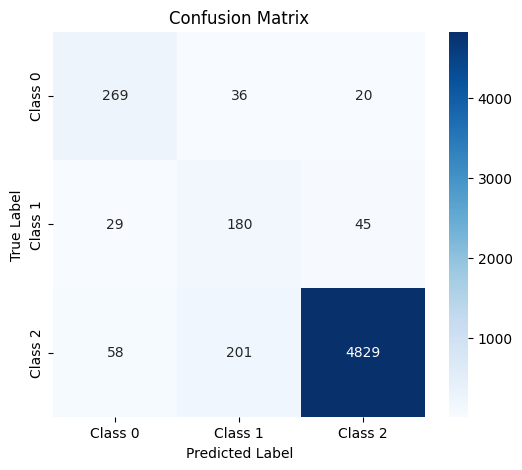

In [231]:
# Get predictions from trainer
predictions = trainer.predict(encoded_dataset["test"])
preds = predictions.predictions.argmax(axis=-1)
labels = predictions.label_ids

# Confusion matrix
cm = confusion_matrix(labels, preds)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1", "Class 2"], yticklabels=["Class 0", "Class 1", "Class 2"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# Product Category Clustering

In [195]:
from transformers import DistilBertModel, DistilBertTokenizerFast

# Load model
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

In [196]:
# Extract embeddings from the trained model (DistilBert)  instead of classification
from transformers import DistilBertModel
import torch
import numpy as np

def get_bert_embeddings(text, tokenizer, model, device='cpu'):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embedding

data_cluster = data[["name"]].drop_duplicates()
# Step 1: Generate BERT embeddings from the text
embeddings = np.vstack([get_bert_embeddings(text, tokenizer, model) for text in data_cluster["name"]])


In [197]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 2: Apply KMeans clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings)

# Step 3: Add cluster labels back to the original DataFrame
data_cluster['cluster'] = cluster_labels

# Step 4: Display basic clustering information
print(f"Cluster labels: {set(cluster_labels)}")
print(data_cluster[['name', 'cluster']].head())


Cluster labels: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}
                                                   name  cluster
0     amazonbasics aaa performance alkaline batterie...        3
8343          amazonbasics nylon cd dvd binder capacity        3
8347                                  amazon echo white        2
8349                             amazon echo show black        2
8350                           echo spot pair kit black        2


In [198]:
# Step 5: Evaluate clustering using Silhouette Score
score = silhouette_score(embeddings, cluster_labels)
print(f"Silhouette Score for KMeans clustering: {score:.4f}")

Silhouette Score for KMeans clustering: 0.1658


In [199]:
# Display number of items in each cluster
cluster_counts = data_cluster['cluster'].value_counts().sort_index()
print("\nNumber of items in each cluster:")
print(cluster_counts)


Number of items in each cluster:
cluster
0     4
1    16
2     5
3    20
4    15
Name: count, dtype: int64


In [232]:
# View sample texts per cluster
for cluster_id in range(n_clusters):
    print(f"\nSample texts from Cluster {cluster_id}:")
    sample_texts = data_cluster[data_cluster['cluster'] == cluster_id]['name'].unique()
    for text in sample_texts:
        print("-", text)


Sample texts from Cluster 0:
- cat litter box covered tray kitten extra large enclosed hooded hidden toilet
- two door top load pet kennel travel crate dog cat pet cage carrier box tray
- amazonbasics single door folding metal dog crate large x x inches
- amazonbasics double door folding metal dog crate medium x x inches

Sample texts from Cluster 1:
- all new fire hd tablet hd display wi fi gb includes special offers black
- fire kids edition tablet display wi fi gb pink kid proof case
- all new fire hd tablet hd display wi fi gb includes special offers magenta
- all new fire tablet with alexa display gb marine blue
- fire tablet display wi fi gb includes special offers black
- all new fire hd tablet hd display wi fi gb includes special offers blue
- fire hd tablet hd display wi fi gb includes special offers silver aluminum
- amazon fire hd with alexa hd display tablet
- all new fire hd kids edition tablet hd display gb pink kid proof case
- all new fire hd kids edition tablet hd dis

In [234]:
# Cluster names based on the analysis of top words
cluster_names = {
    0: "Pet Supplies & Small Home Goods",
    1: "Fire Tablets & Accessories",
    2: "Amazon Echo & Smart Speakers",
    3: "AmazonBasics & General Tech Accessories",
    4: "Kindle E-Readers & Charging Accessories"
}


# Map cluster names to the data
data_cluster['cluster_name'] = data_cluster['cluster'].map(cluster_names)

# Show the resulting cluster names and reviews
cluster_counts = data_cluster['cluster_name'].value_counts().sort_index()

# Print the number of items in each cluster
print("\nNumber of items in each cluster:")
print(cluster_counts)


print("\nSample Data:")
data_cluster


Number of items in each cluster:
cluster_name
Amazon Echo & Smart Speakers                5
AmazonBasics & General Tech Accessories    20
Fire Tablets & Accessories                 16
Kindle E-Readers & Charging Accessories    15
Pet Supplies & Small Home Goods             4
Name: count, dtype: int64

Sample Data:


,name,cluster,cluster_name
0,amazonbasics aaa performance alkaline batterie...,3,AmazonBasics & General Tech Accessories
8343,amazonbasics nylon cd dvd binder capacity,3,AmazonBasics & General Tech Accessories
8347,amazon echo white,2,Amazon Echo & Smart Speakers
8349,amazon echo show black,2,Amazon Echo & Smart Speakers
8350,echo spot pair kit black,2,Amazon Echo & Smart Speakers
8352,fire tv stick streaming media player pair kit,3,AmazonBasics & General Tech Accessories
8358,amazonbasics aa performance alkaline batteries...,3,AmazonBasics & General Tech Accessories
12086,amazonbasics ventilated adjustable laptop stand,3,AmazonBasics & General Tech Accessories
12098,amazonbasics backpack for laptops up to inches,3,AmazonBasics & General Tech Accessories
12123,amazonbasics inch laptop sleeve,3,AmazonBasics & General Tech Accessories


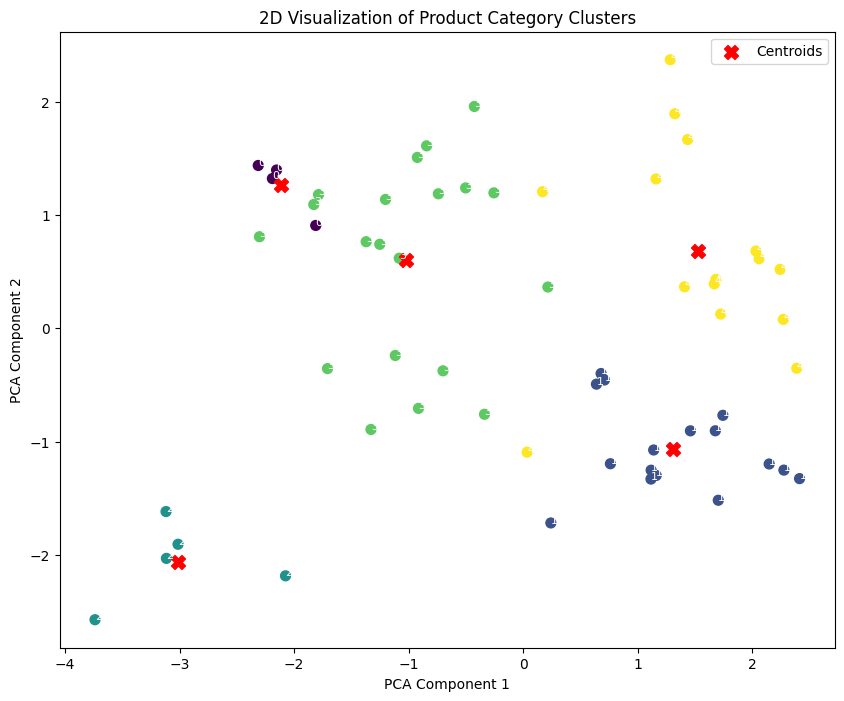

In [235]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply PCA for 2D visualization of the BERT embeddings
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# Plot the clusters
plt.figure(figsize=(10, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title('2D Visualization of Product Category Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Add cluster centroids to the plot
centroids = kmeans.cluster_centers_
reduced_centroids = pca.transform(centroids)
plt.scatter(reduced_centroids[:, 0], reduced_centroids[:, 1], c='red', marker='X', s=100, label='Centroids')

# Display cluster labels
for i, label in enumerate(cluster_labels):
    plt.text(reduced_embeddings[i, 0], reduced_embeddings[i, 1], str(label), color='white', fontsize=8)

plt.legend()
plt.show()


In [236]:
import pandas as pd
from google.colab import files

# Save the DataFrame to a CSV file
data_cluster.to_csv('data_cluster.csv', index=False)
files.download('data_cluster.csv')
data_cluster

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,name,cluster,cluster_name
0,amazonbasics aaa performance alkaline batterie...,3,AmazonBasics & General Tech Accessories
8343,amazonbasics nylon cd dvd binder capacity,3,AmazonBasics & General Tech Accessories
8347,amazon echo white,2,Amazon Echo & Smart Speakers
8349,amazon echo show black,2,Amazon Echo & Smart Speakers
8350,echo spot pair kit black,2,Amazon Echo & Smart Speakers
8352,fire tv stick streaming media player pair kit,3,AmazonBasics & General Tech Accessories
8358,amazonbasics aa performance alkaline batteries...,3,AmazonBasics & General Tech Accessories
12086,amazonbasics ventilated adjustable laptop stand,3,AmazonBasics & General Tech Accessories
12098,amazonbasics backpack for laptops up to inches,3,AmazonBasics & General Tech Accessories
12123,amazonbasics inch laptop sleeve,3,AmazonBasics & General Tech Accessories


#Task 3. Summarize reviews using generative AI

In [187]:
!pip install openai

In [237]:
from openai import OpenAI
from google.colab import userdata
api_key = userdata.get('OPENAI_API')
client = OpenAI(api_key=api_key)
response = client.chat.completions.create(
    model="gpt-4",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Hello!"}
    ]
)

In [238]:
# Extract top 3 and worst product per category
def get_top_and_worst_products(df, n_top=3):
    # Group by product name, calculate average rating and number of reviews
    grouped = df.groupby("name")['reviews.rating'].agg(['mean', 'count']).reset_index()

    # Filter out products with less than 5 reviews (to avoid bias from too few ratings)
    grouped = grouped[grouped['count'] >= 5]

    # Get the top n products with highest average rating
    top_products = grouped.sort_values(by="mean", ascending=False).head(n_top)['name'].tolist()

    # Get the single product with the lowest average rating
    worst_product = grouped.sort_values(by="mean", ascending=True).head(1)['name'].values[0]

    return top_products, worst_product

# Get top complaints for a given product
def get_top_complaints(df, product_name, n_complaints=3):
    # Filter reviews for the given product
    product_reviews = df[df['name'] == product_name]

    # Select only reviews with low ratings (2 stars or less)
    low_rated_reviews = product_reviews[product_reviews['reviews.rating'] <= 2]

    # Get the text of the top n most relevant complaints
    top_complaints = low_rated_reviews.sort_values(by='reviews.rating').head(n_complaints)['reviews.text'].tolist()
    return top_complaints

# Generate a blog-style summary article using GPT
def generate_summary(category, top_products, complaints_dict, worst_product, worst_reason):
    messages = [
        {"role": "system","content": "You are a helpful assistant who writes product review summaries like a blog post."},
        {"role": "user", "content": f"""
Write a short blog-style article for the category '{category}'.

1. Recommend the top 3 products: {top_products}.
2. Explain the key differences between them.
3. List the top complaints users had about each product: {complaints_dict}.
4. Also, mention the worst product in this category: '{worst_product}', and explain why users should avoid it based on complaints like: {worst_reason}.
"""}
    ]

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages,
        temperature=0.7,
    )
    return response.choices[0].message.content

In [240]:
# Example
# Step 1: Choose the category
category = "Amazon Echo & Smart Speakers"
# Call the functions
top_products, worst_product = get_top_and_worst_products(df.copy())

complaints_dict = {}
for product in top_products:
    complaints_dict[product] = get_top_complaints(df.copy(), product)

worst_reason = get_top_complaints(df.copy(), worst_product)

summary = generate_summary(category, top_products, complaints_dict, worst_product, worst_reason)
print(summary)

When it comes to Amazon Echo & Smart Speakers, having the right accessories can make a world of difference in enhancing your overall experience. Let's take a look at the top 3 recommended products in this category and also highlight one product you might want to steer clear of.

**Top 3 Recommended Products:**

1. **AmazonBasics Gauge Speaker Wire (100 Feet):** This speaker wire is perfect for setting up your audio system with ease. It provides clear sound transmission and is durable for long-term use.

2. **AmazonBasics USB Cable A Male to B Male (6 Feet/1.8 Meters):** This USB cable is essential for connecting your smart devices and peripherals. With a convenient length of 6 feet, it offers flexibility and fast data transfer.

3. **Expanding Accordion File Folder:** Stay organized with this portable document organizer. Ideal for storing letters and important papers, this file folder is a must-have for keeping your workspace tidy.

**Key Differences:**

- The speaker wire is designed 

In [241]:
import joblib
joblib.dump(model, 'review_classification_model.joblib')
print("Model saved successfully!")


Model saved successfully!
